# テーマ2 データ可視化とEDA

## 目的
- EDA を「モデル作成前の観察と仮説づくり」として理解する
- 分布、グループ差、変数の関係をグラフで確認し、読み方を覚える
- グラフを見て、特徴量の違いやクラスごとの傾向を言葉で説明する

## 今日の成果物
- ヒストグラム、箱ひげ図、散布図を含むグラフを3つ以上作る
- それぞれのグラフから読み取れることを短く記述する

## 注意
- このNotebookは上から順に実行してください
- `TODO` は小さな変更で進められるようにしてあります

## EDAとは何か

EDA は Exploratory Data Analysis の略で、日本語では探索的データ分析と呼ばれます。
目的は、モデルを作る前にデータを観察して仮説を立てることです。

この回では、数値計算よりも**グラフを読むこと**を重視します。

| 観点 | 見るもの | 使うグラフ |
| --- | --- | --- |
| 構成比 | クラスやカテゴリの割合 | 円グラフ、棒グラフ |
| 分布 | 値がどの範囲に多いか | ヒストグラム |
| グループ差（平均） | クラスごとの平均 | 折れ線グラフ |
| グループ差（詳細） | クラスごとの中央値・ばらつき | 箱ひげ図 |
| 関係 | 2つの変数のつながり | 散布図 |

EDA では 「グラフ を作った」 で終わらず、**「その グラフ から何が言えそうか」** を
書くまで行います。

### グラフを読むときの型

グラフを見たら、次の3つを分けて書くと考えやすくなります。

1. **事実**: 図にそのまま見えていること
2. **解釈**: その事実から考えられること
3. **限界**: その図だけではまだ言えないこと

**例:** `petal length (cm)` は品種ごとに分布が分かれて見える。
これは分類に役立つ特徴量かもしれない。ただし、図だけでは新しいデータを
必ず正しく分類できるとは言えない。

### 分析の流れ

このノートブックでは、Iris データを使って可視化の練習をします。

| Step | やること | 確認する観点 |
| --- | --- | --- |
| 0 | ライブラリとデータを準備 | 環境設定 |
| 1 | データを確認 | 行数、列名、概要 |
| 2 | シンプルなヒストグラム | 値の広がり、山の形 |
| 3 | ヒストグラム（品種ごと） | グループごとに分布を見る |
| 4 | 折れ線グラフで平均を確認 | 複数特徴量を一度に比べる |
| 5 | 円グラフでクラスの構成比 | 各クラスがバランスよくあるか |
| 6 | 箱ひげ図でグループ詳細 | 中央値、ばらつき、外れ値 |
| 7 | 散布図で2つの特徴量の関係 | 特徴量どうしの関連性 |

後半に「追加グラフ」と「ワインデータセットを使った演習」があります。
それらは発展なので、まず基本を完成させてから進みましょう。

---

### Step 0: グラフ描画の準備

matplotlib と seaborn を読み込みます。以降、グラフ関数を使い
`plt.show()` で表示します。

In [83]:
# ===== ライブラリ読み込み =====
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_wine

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Hiragino Sans', 'Yu Gothic', 'Arial Unicode MS', 'DejaVu Sans'
]

---

### Step 1: データを読み込む

Iris データを DataFrame にします。
（テーマ1 で同じ操作をしています。ここでは、確認として読み込みます。）

In [84]:
# ===== Step 1: データ読み込み =====
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))
numeric_columns = iris.feature_names

print('行数, 列数 =', df.shape)
print('数値列 =', numeric_columns)
display(df.head())

行数, 列数 = (150, 6)
数値列 = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


---

### Step 2: シンプルなヒストグラム

**最初に** 1つの特徴量の値がどう広がっているかを確認します。
どの範囲にデータが多いか、山が1つか複数か、極端な値がありそうかを見ます。

**初心者のためにシンプルに** KDE 曲線は使わず、
棒グラフのみで表示します。これで分布の全体像がわかります。

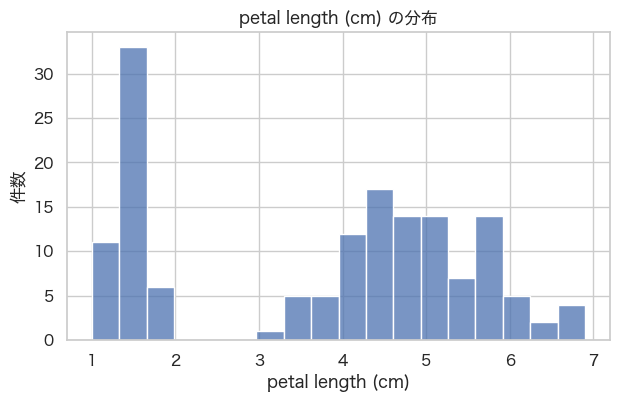

In [85]:
# ===== Step 2: シンプルなヒストグラム =====
# TODO: feature を別の列に変えて、分布の違いを確認する
feature = 'petal length (cm)'

plt.figure(figsize=(7, 4))
sns.histplot(data=df, x=feature, bins=18)
plt.title(f'{feature} の分布')
plt.xlabel(feature)
plt.ylabel('件数')
plt.show()

**この図を見ると:**
- 横軸が値、縦軸が件数です。
- ピーク（山）はどの位置にありますか？
- 値の範囲はどこですか？

---

### Step 3: 品種ごとのヒストグラム

Step 2 のヒストグラムは全体の分布でしたが、次は**各クラスごとに色分け**して見ます。

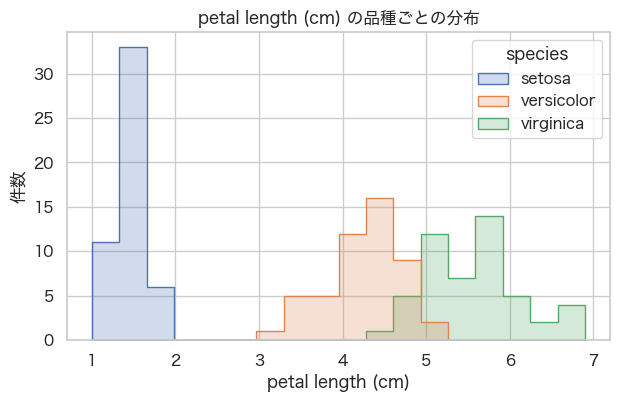

In [86]:
# ===== Step 3: 品種ごとのヒストグラム =====
# TODO: feature を変えて、品種ごとの差が見えやすい列を探す
feature = 'petal length (cm)'

plt.figure(figsize=(7, 4))
sns.histplot(
    data=df,
    x=feature,
    hue='species',
    bins=18,
    element='step'
)
plt.title(f'{feature} の品種ごとの分布')
plt.xlabel(feature)
plt.ylabel('件数')
plt.show()

**観察のポイント:**
- setosa の`petal length` は短い方に、virginica は長い方に分布している。
- versicolor と virginica は一部重なっているが、全体として分かれている。

---

### Step 4: 折れ線グラフで品種ごとの平均を確認

**折れ線グラフは平均の違いをまとめて見る可視化** です。
箱ひげ図は1つの特徴量に注目しましたが、折れ線グラフなら
**複数の特徴量を一度**比べられます。

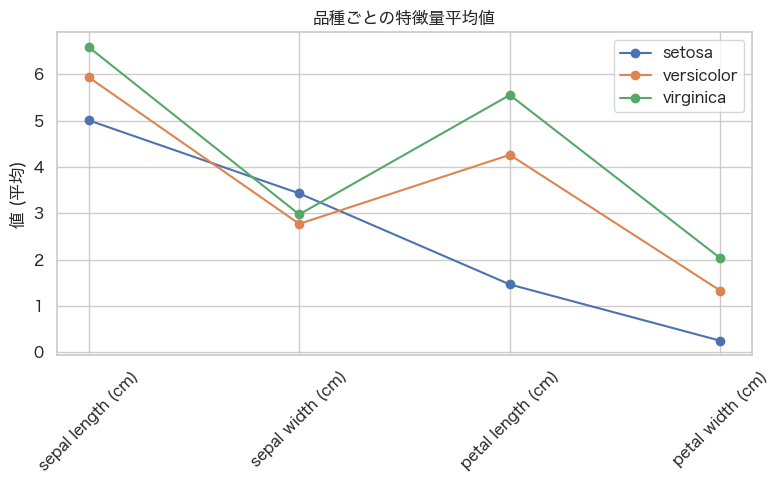

In [87]:
# ===== Step 4: 折れ線グラフ =====
# TODO: どの品種でどの特徴量に差が大きいかを確認する
mean_by_species = df.groupby('species')[iris.feature_names].mean()

plt.figure(figsize=(8, 5))
for species in mean_by_species.index:
    plt.plot(
        mean_by_species.columns,
        mean_by_species.loc[species],
        marker='o',
        label=species
    )

plt.title('品種ごとの特徴量平均値')
plt.xticks(rotation=45)
plt.legend()
plt.ylabel('値 (平均)')
plt.tight_layout()
plt.show()

**観察のポイント:**
- petal の2つで品種ごとの開き（差）が sepal より大きい。
- 折れ線の順序と品種の対応関係、重なり方も確認できる。

---

### Step 5: 円グラフでクラスの構成比を見る

分析の入り口として、各クラスが何サンプルずつあるかを確認します。
クラス間に大きな偏りがある場合、モデルの評価に影響することがあるので
最初にチェックしておくと安心です。

#### 解説: 円グラフとは

円グラフは、カテゴリごとの割合を視覚的に把握するのに適しています。
全体に対する各クラスの大きさがひと目でわかります。

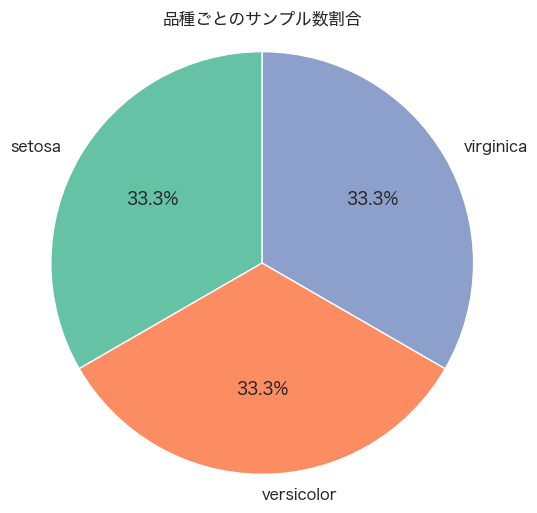

In [88]:
# ===== Step 5: 円グラフ =====
# TODO: 各品種の割合がどうなっているか確認する
species_count = df['species'].value_counts()

plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(
    species_count.values,
    labels=species_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66c2a5', '#fc8d62', '#8da0cb']
)
plt.title('品種ごとのサンプル数割合')
plt.axis('equal')
plt.show()

**観察のポイント:**
- 3品種がそれぞれ約33.3%ずつの割合になっている。
- クラス間の偏りがないため、各品種を同程度に扱って観察しやすい。

---

### Step 6: 箱ひげ図でグループごとの差を見る

ヒストグラムは分布の全体像を見るのに向いています。
箱ひげ図では、品種ごとの中央値やばらつきの**違い**を比較しやすくします。

#### 解説: 箱ひげ図の読み方

箱ひげ図は、値の分布を5つの代表値で簡潔に表します。

| 要素 | 意味 |
| --- | --- |
| 箱の中央線 | **中央値**（データの真ん中の値）|
| 箱の下端 | 第1四分位数（下から25%の位置）|
| 箱の上端 | 第3四分位数（下から75%の位置）|
| ひげ | データの大半が入る範囲 |
| 点 | 外れ値候補として表示される値 |

グループごとの箱の位置が大きく違えば、その特徴量は
グループの違いを説明する手がかりになります。

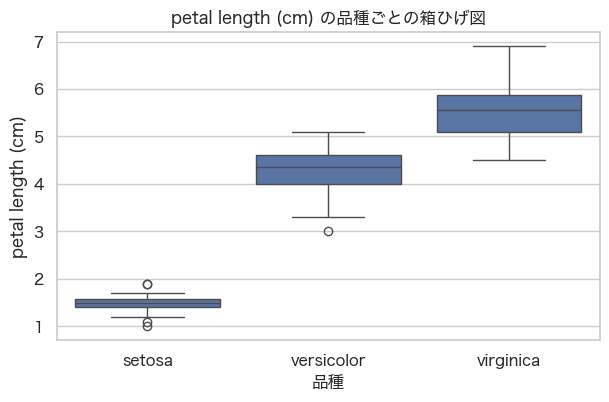

In [89]:
# ===== Step 6: 箱ひげ図 =====
# TODO: target_feature を別の列に変えて、分かれやすい特徴量を探す
target_feature = 'petal length (cm)'

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='species', y=target_feature)
plt.title(f'{target_feature} の品種ごとの箱ひげ図')
plt.xlabel('品種')
plt.ylabel(target_feature)
plt.show()

**観察のポイント:**
- 3品種の箱がお互いに離れた位置にある → この特徴量で品種を区別しやすい
- 箱の高さが小さい → その品種の中ではばらつきが小さい
- 箱が重なっている → どの品種に属するか判断しにくい領域がある

---

### Step 7: 散布図で2つの特徴量の関係を見る

散布図では、2つの特徴量を見て、「一緒に動くか」「品種によって分かれるか」を確認できます。

#### 解説: 散布図の読み方

| 並び方 | 意味 |
| --- | --- |
| 右上がりに並ぶ | 正の相関（片方が大きいとその方も大きい）|
| 右下がりに並ぶ | 負の相関（片方が大きいとその方は小さい）|
| ばらばら | 明確な関係が見えにくい |
| 色でグループに分かれる | その2つの特徴量で品種を区別できる可能性 |

ここでは相関係数の計算ではなく、見た目で傾向を読み取ります。

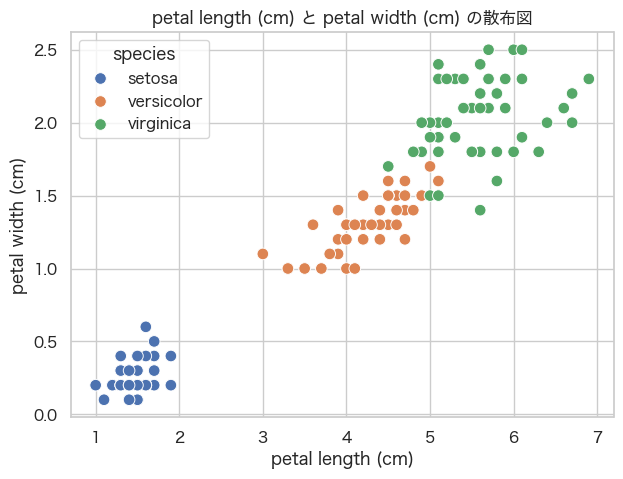

In [90]:
# ===== Step 7: 散布図 =====
# TODO: x_feature と y_feature を変えて、品種が分かれやすい組み合わせを探す
x_feature = 'petal length (cm)'
y_feature = 'petal width (cm)'

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x=x_feature, y=y_feature, hue='species', s=70)
plt.title(f'{x_feature} と {y_feature} の散布図')
plt.xlabel(x_feature)
plt.ylabel(y_feature)
plt.show()

**観察のポイント:**
- setosa が左上に、virginica が右下に集まっている → petal の2つでよく区別できる
- versicolor は setosa と virginica の中間に位置している
- 右上がりの傾向がある → petal length と petal width は正の相関がある

---

## 追加グラフ（発展）

ここからはさらに3つのグラフを紹介します。

### ヒートマップで相関を確認

散布図は2変数ずつ見る方法でした。ヒートマップを使えば**特徴量どうしの関係を一度に数値で**確認できます。

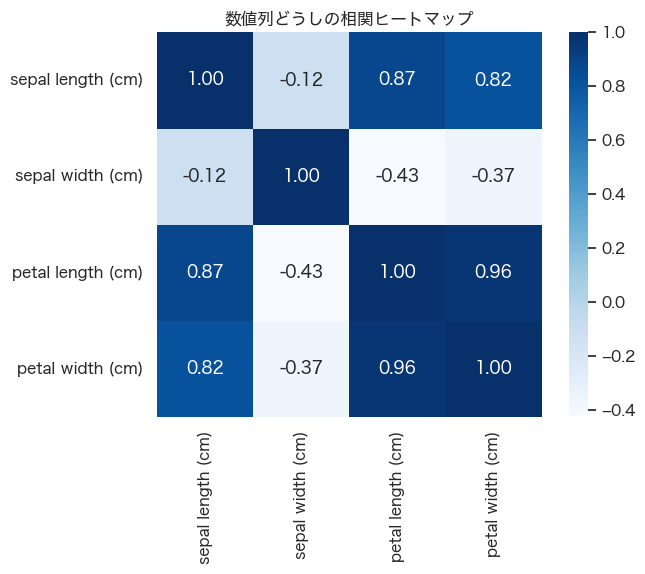

In [91]:
# ===== 相関ヒートマップ =====
corr_matrix = df[numeric_columns].corr(numeric_only=True)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', square=True)
plt.title('数値列どうしの相関ヒートマップ')
plt.show()

### pairplot で全体像を確認

ここで紹介するpairplot は、すべての特徴量どうしの散布図を一緒に並べます。
対角線には各特徴量の分布が描かれます。

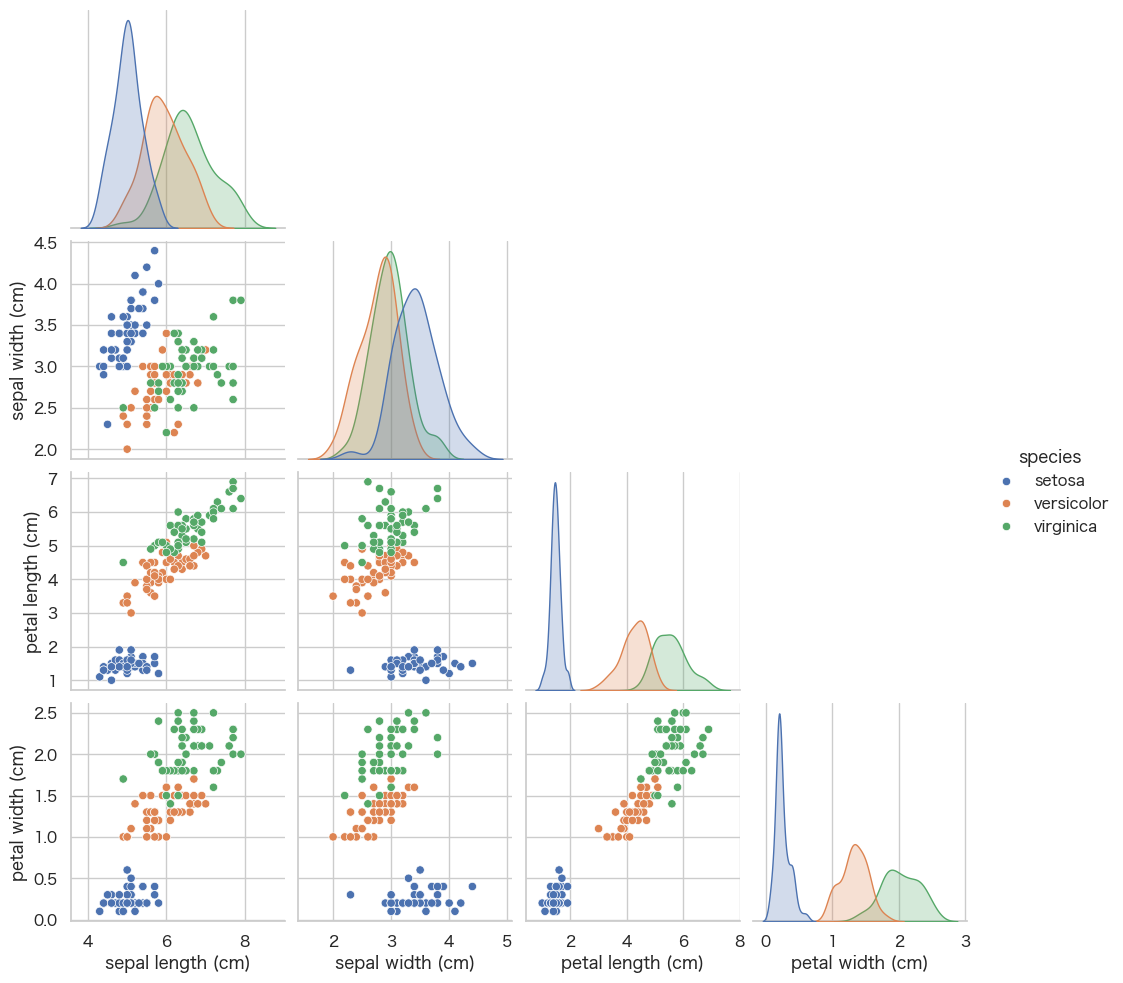

In [92]:
# ===== pairplot =====
pairplot_columns = iris.feature_names + ['species']
g = sns.pairplot(df[pairplot_columns], hue='species', corner=True)
plt.show()

### IQR で外れ値の候補を探す

箱ひげ図で外れ値を目で確認できましたが、ここでは数値でも見てみます。

**IQR の考え方:**
- `IQR = Q3 - Q1` （第3四分位数 - 第1四分位数）
- 下限: `Q1 - 1.5 × IQR`
- 上限: `Q3 + 1.5 × IQR`
- この範囲外にある値を「外れ値候補」とします

In [93]:
# ===== IQR で外れ値候補を確認 =====
# TODO: feature_to_check を変えて、外れ値候補の件数を確認する
feature_to_check = 'sepal width (cm)'

q1   = df[feature_to_check].quantile(0.25)
q3   = df[feature_to_check].quantile(0.75)
iqr  = q3 - q1
low  = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr

outliers = df[
    (df[feature_to_check] < low) | (df[feature_to_check] > high)
]

print('確認する列 =', feature_to_check)
print('下限 =', round(low, 2))
print('上限 =', round(high, 2))
print('外れ値候補の件数 =', len(outliers))
display(outliers[[feature_to_check, 'species']].head())

確認する列 = sepal width (cm)
下限 = 2.05
上限 = 4.05
外れ値候補の件数 = 4


,sepal width (cm),species
15,4.4,setosa
32,4.1,setosa
33,4.2,setosa
60,2.0,versicolor


### レーダーチャートで品種を比較する

レーダーチャートは、各特徴量を**角度方向に配置し、品種ごとの平均値を輪郭**として描きます。
形が異なれば、品種ごとの特徴の傾向が見えやすくなります。

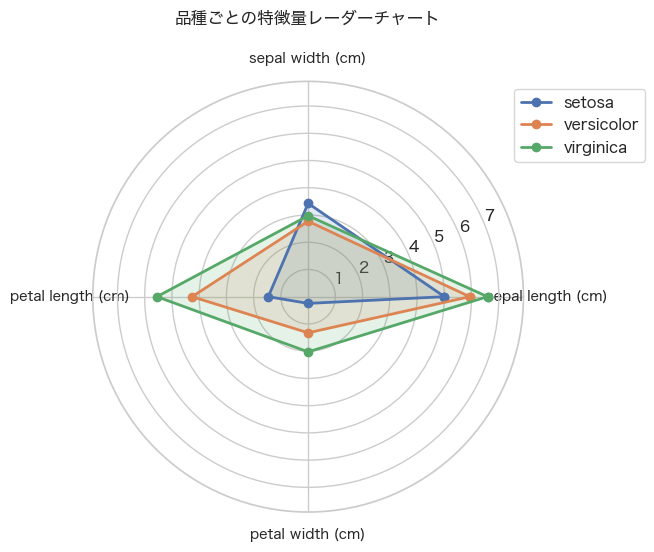

In [94]:
# ===== レーダーチャート =====
# TODO: 生成された図形から、どの品種が最も幅広い輪郭を持つかを確認する
import numpy as np

mean_by_species = df.groupby('species')[iris.feature_names].mean()
features = iris.feature_names
num_vars = len(features)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # 閉じるために最初の角度を最後に追加

plt.figure(figsize=(7, 7))
ax = plt.subplot(111, projection='polar')

for species in mean_by_species.index:
    values = mean_by_species.loc[species].values.flatten().tolist()
    values += values[:1]  # 閉じるために最初の値を最後に追加
    ax.plot(angles, values, linewidth=2, label=species, marker='o')
    ax.fill(angles, values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=10)
ax.set_ylim(0, max(mean_by_species.max()) * 1.2)
ax.set_title('品種ごとの特徴量レーダーチャート', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.show()

---

## 演習: ワインデータセットでEDAを練習

ここからは、Iris とは別のデータセットを使って同じ流れの EDA を行います。

**ワインデータセット** は 13 個の特徴量を持ち、クラス数も Iris と同じ 3 つです。
特徴量の名前は英語なので、列の意味までは理解しなくて大丈夫です。

前のステップで作ったコードを、`wine_df` と `class_name` に読み替えて使いまわしてください。

In [95]:
# ===== ワインデータの準備 =====
wine = load_wine(as_frame=True)
wine_df = wine.frame.copy()
wine_df['class_name'] = wine_df['target'].map(
    dict(enumerate(wine.target_names))
)
wine_numeric_columns = wine.feature_names

print('行数, 列数 =', wine_df.shape)
print('クラス =', list(wine.target_names))
print ('特徴量（一部）= ', wine_numeric_columns[:5])
display(wine_df.head())

行数, 列数 = (178, 15)
クラス = [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
特徴量（一部）=  ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


**以下の課題に答えながら進めてください。**

---

**課題1（ヒストグラム）:** `wine_numeric_columns` から1つ選び、
円グラフと同様にクラスの構成比と、その特徴量のクラス別分布をヒストグラムで確認してください。

**課題2（箱ひげ図）:** 別の特徴量を選んで箱ひげ図を描き、
3クラスの差を確認してください。Iris の場合と、どの部分が似ていて・違うかメモしておきましょう。

**課題3（散布図）:** 2つの特徴量を選び、
クラスが分かれて見えるか確認してください。

**課題4（IQR検査）:** IQR を使って外れ値の候補を調べ、
どの列に注目したかを1〜2行書いてください。

---

---

## まとめと振り返り

この回の EDA で確認できたことを整理しましょう。

### 振り返り課題

以下の問いに短く回答してください。

**Q1. シンプルなヒストグラムから、どの特徴量の分布が品種ごとに分かれて見えましたか。**

---

**Q2. 折れ線グラフから、どの特徴量で品種の差が大きかったですか。**

---

**Q3. 箱ひげ図から、品種ごとの差が大きい特徴量はどれでしたか。**
理由を1文で書いてください。

---

**Q4. 散布図で品種が分かれて見えやすい特徴量の組み合わせはどれでしたか。**

---

**Q5. この回で作成したグラフのうち、印象に残ったものを1つ選び、**
**「事実」「解釈」「限界」の3つの型を使って説明してください。**

- 事実: 
- 解釈: 
- 限界: 

---

**Q6. ワインデータの演習を通じて、Iris と比べてどの部分が**
**読み取りやすかったか（あるいは難しかったか）を1〜2行で書いてください。**